# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [32]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

## Exploratory Data Analysis  
- Load in the cleaned data

In [33]:
df = pd.read_csv('Aviation_cleaned.csv',encoding='latin1')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [34]:
#Creating small and large aircraft dataframes
threshold= 20
df_small = df[df['total_passengers'] <= threshold]
df_large = df[df['total_passengers'] >= threshold]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [35]:
#Getting the 15 make for the small aircraft df
small_make15 = df_small.groupby('make')['serious_and_fatal_fraction'].agg(['mean']).sort_values('mean').head(15)

#Getting the 15 make for the large aircraft df
large_make15 = df_large.groupby('make')['serious_and_fatal_fraction'].agg(['mean']).sort_values('mean').head(15)

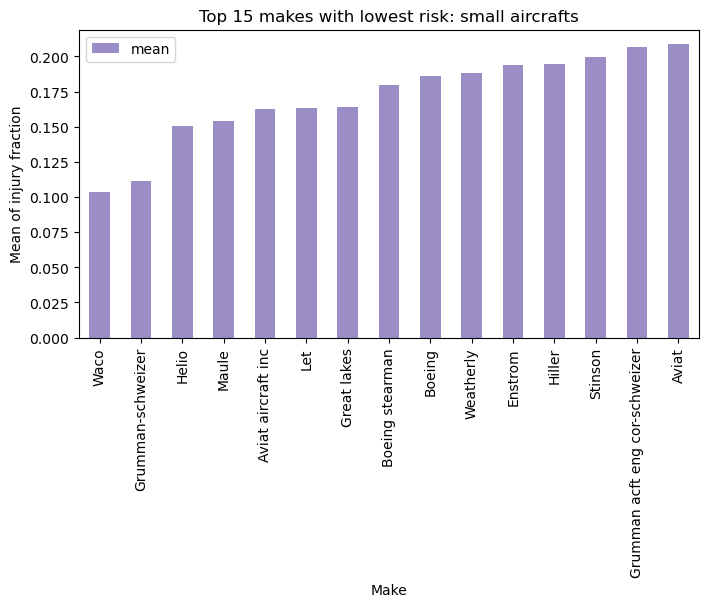

In [54]:
#Plotting the two df agaisnt each other

#plotting bar graph to represent small make
small_make15.plot(kind='bar', color='#9B8EC7', figsize=(8,4))
plt.title('Top 15 makes with lowest risk: small aircrafts')
plt.xlabel('Make')
plt.ylabel('Mean of injury fraction')


plt.show()

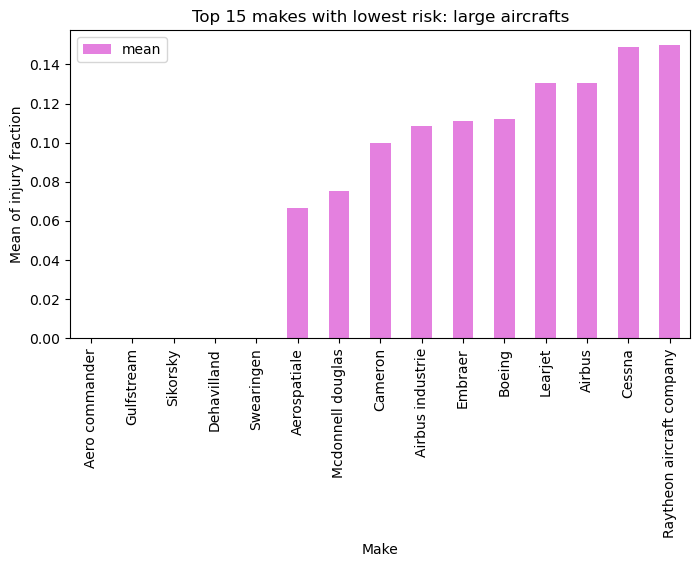

In [37]:
#plotting bar graph to represent large make with least risk
large_make15.plot(kind='bar', color="#E480DF", figsize=(8,4))
plt.title('Top 15 makes with lowest risk: large aircrafts')
plt.xlabel('Make')
plt.ylabel('Mean of injury fraction')

plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

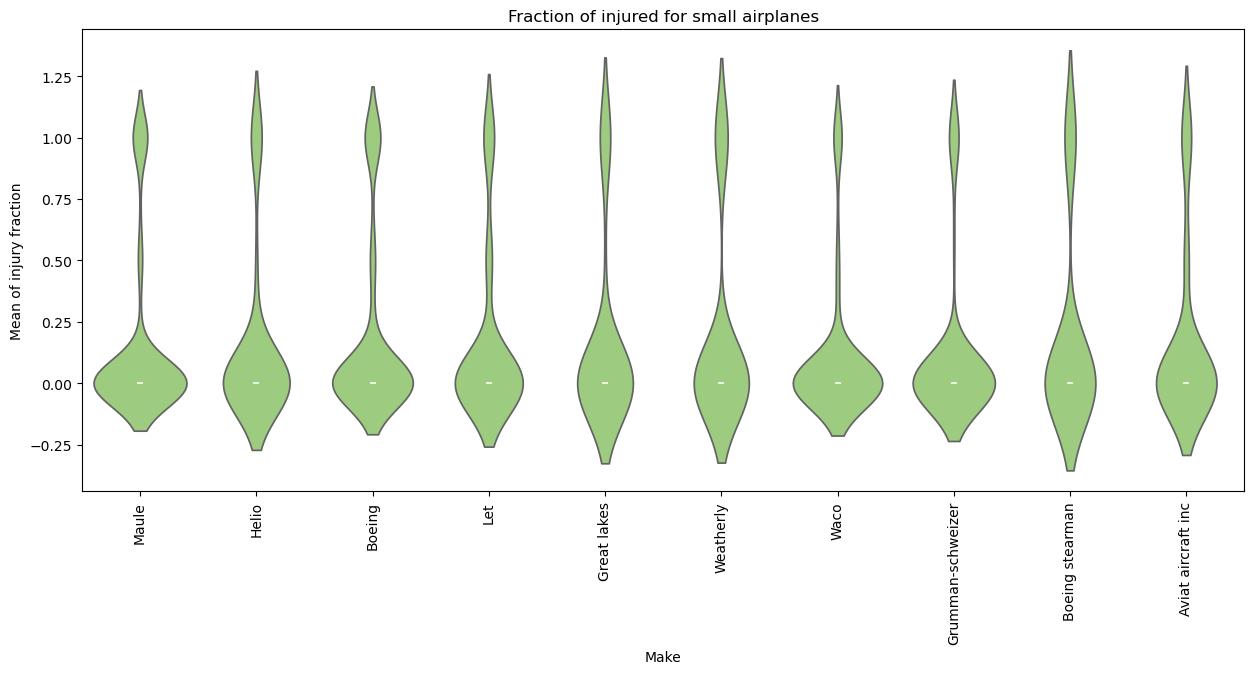

In [38]:
#Getting  the makes with lowest injury fraction
small_make10 = small_make15.head(10).index
small_plot = df_small[df_small['make'].isin(small_make10)]

fig, ax = plt.subplots(figsize=(15,6))

sns.violinplot(data=small_plot, x='make',y='serious_and_fatal_fraction', color='#9AD872')
plt.title('Fraction of injured for small airplanes')
plt.xlabel('Make')
plt.ylabel('Mean of injury fraction')
plt.xticks(rotation=90)

plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

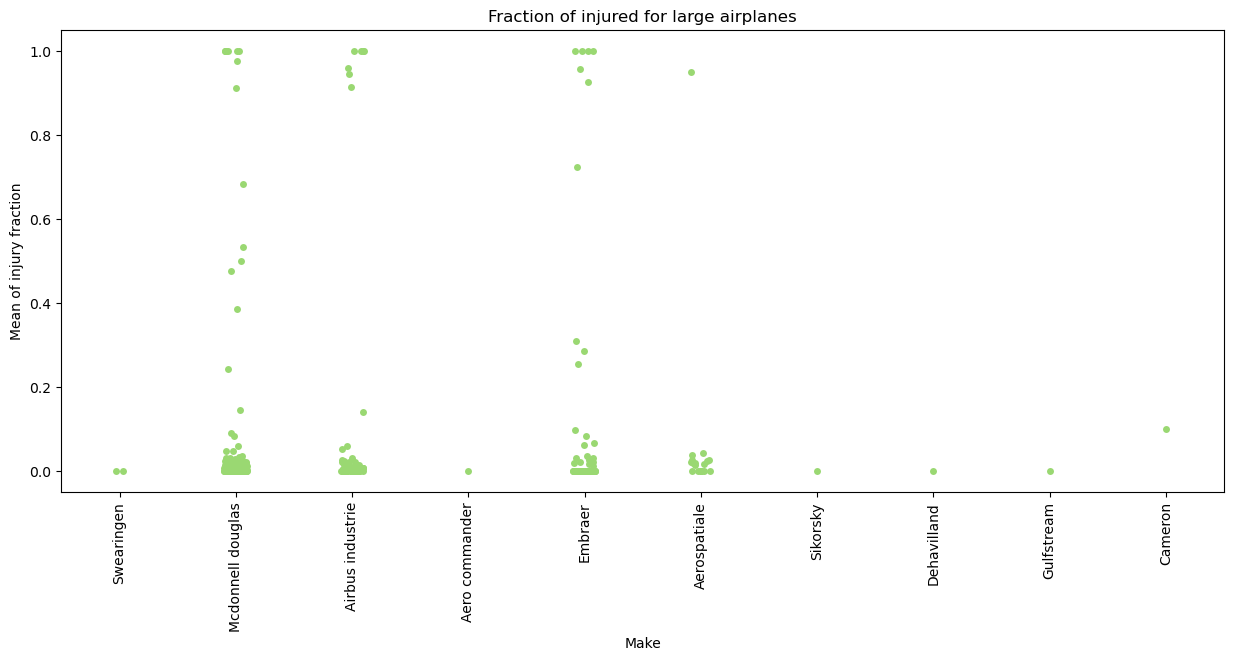

In [39]:
large_make10 = large_make15.head(10).index
large_plot = df_large[df_large['make'].isin(large_make10)]

fig, ax = plt.subplots(figsize=(15,6))

sns.stripplot(data=large_plot, x='make',y='serious_and_fatal_fraction', color='#9AD872')
plt.title('Fraction of injured for large airplanes')
plt.xlabel('Make')
plt.ylabel('Mean of injury fraction')
plt.xticks(rotation=90)

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

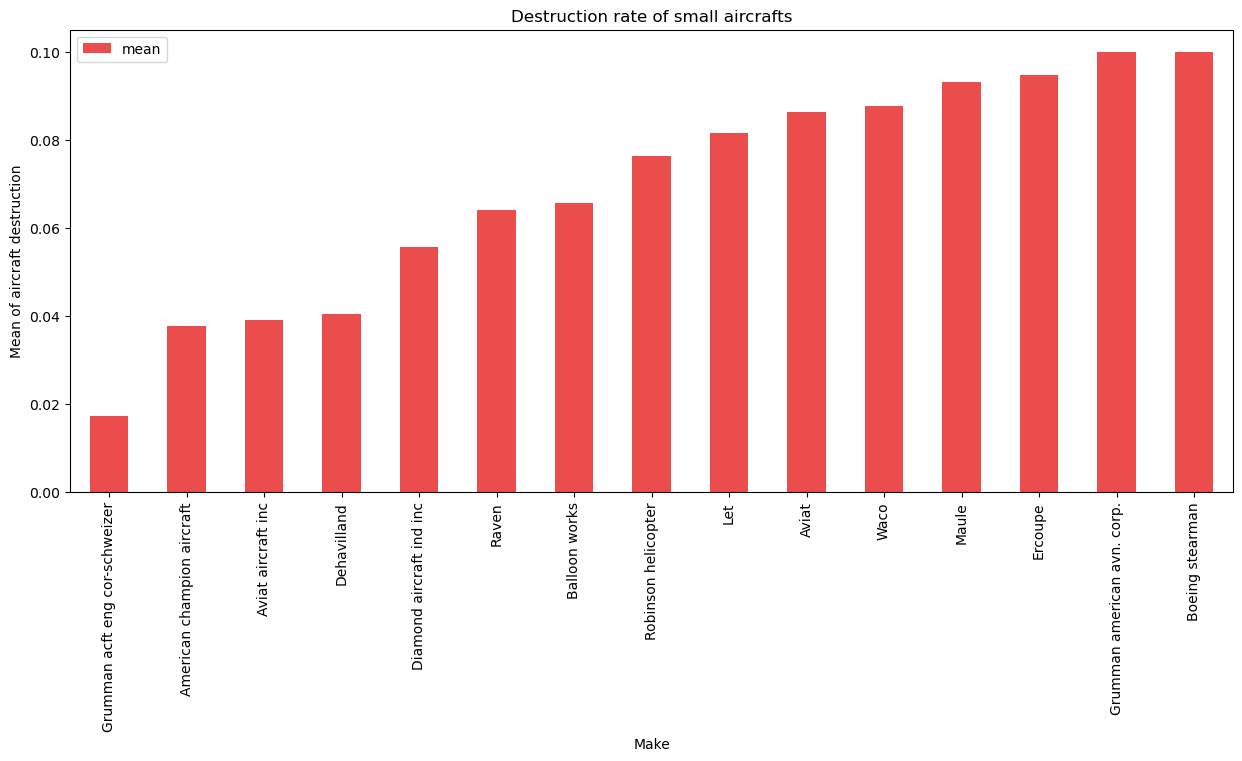

In [40]:
#aircraft destruction accorfing to small aircraft
small_destruction = df_small.groupby('make')['aircraft_destroyed'].agg(['mean']).sort_values('mean').head(15)

small_destruction.plot(kind='bar', color="#EB4C4C", figsize=(15,6))

plt.title('Destruction rate of small aircrafts')
plt.xlabel('Make')
plt.ylabel('Mean of aircraft destruction')

plt.show()


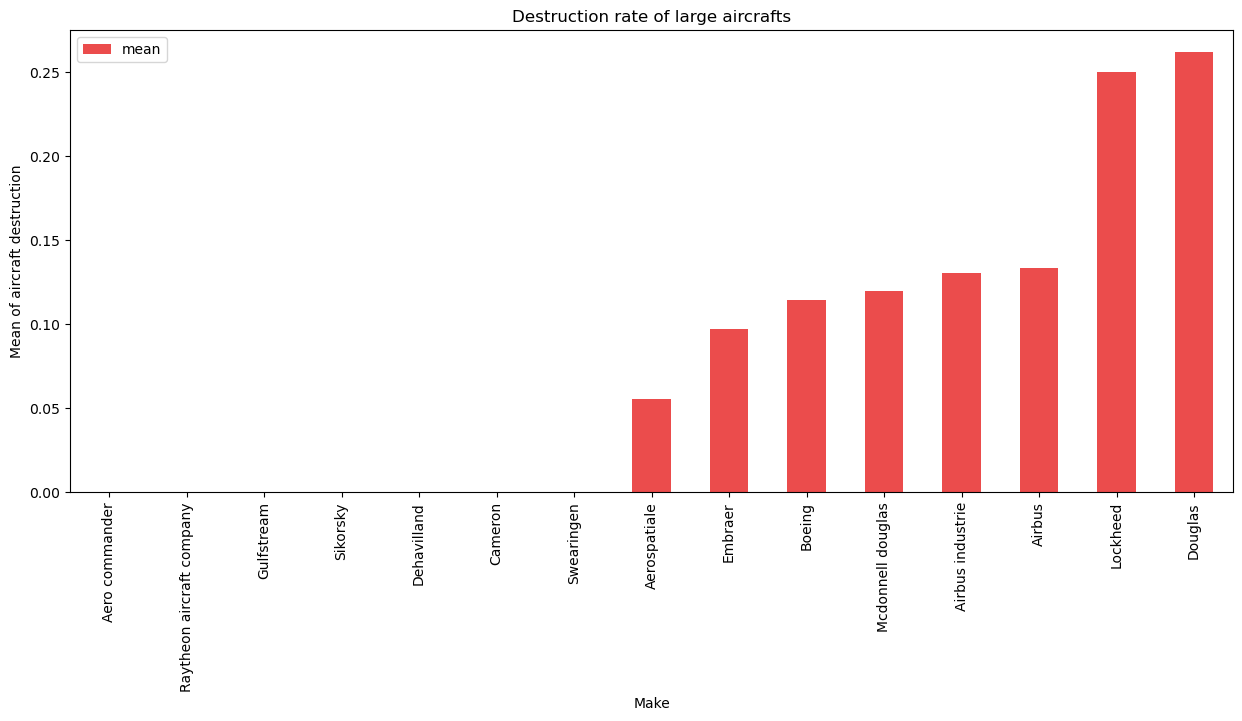

In [41]:
#aircraft destruction accorfing to large aircraft
large_destruction = df_large.groupby('make')['aircraft_destroyed'].agg(['mean']).sort_values('mean').head(15)

large_destruction.plot(kind='bar', color="#EB4C4C", figsize=(15,6))

plt.title('Destruction rate of large aircrafts')
plt.xlabel('Make')
plt.ylabel('Mean of aircraft destruction')

plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Insights from above plots:
- Smaller aircrafts like Waco and Grumman-schweizer are linked to the lowest injury at a fraction belowe 0.125. The violin plot shows that most of the makes are clustered around 0, however, it doesnt neccessarily tell us which make is more safer. In the rates of destruction, Grumman acft eng cor-schweizer and American champion had the lowest rate at a frcartion below 0.04.
- Larger aircrafts have a total of 5 different make with a rate of 0 on the scale of serious injuries  and the stripplot indicated that most of them concerntrate on 0. In relation to destruction, it has a total of 7 makes that result in 0 on the rate of destruction of aircraft fraction.
- In conclusion, according to the 15 selected makes, larger planes are linked to less severe outcome of injury and destruction compared to smaller planes.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

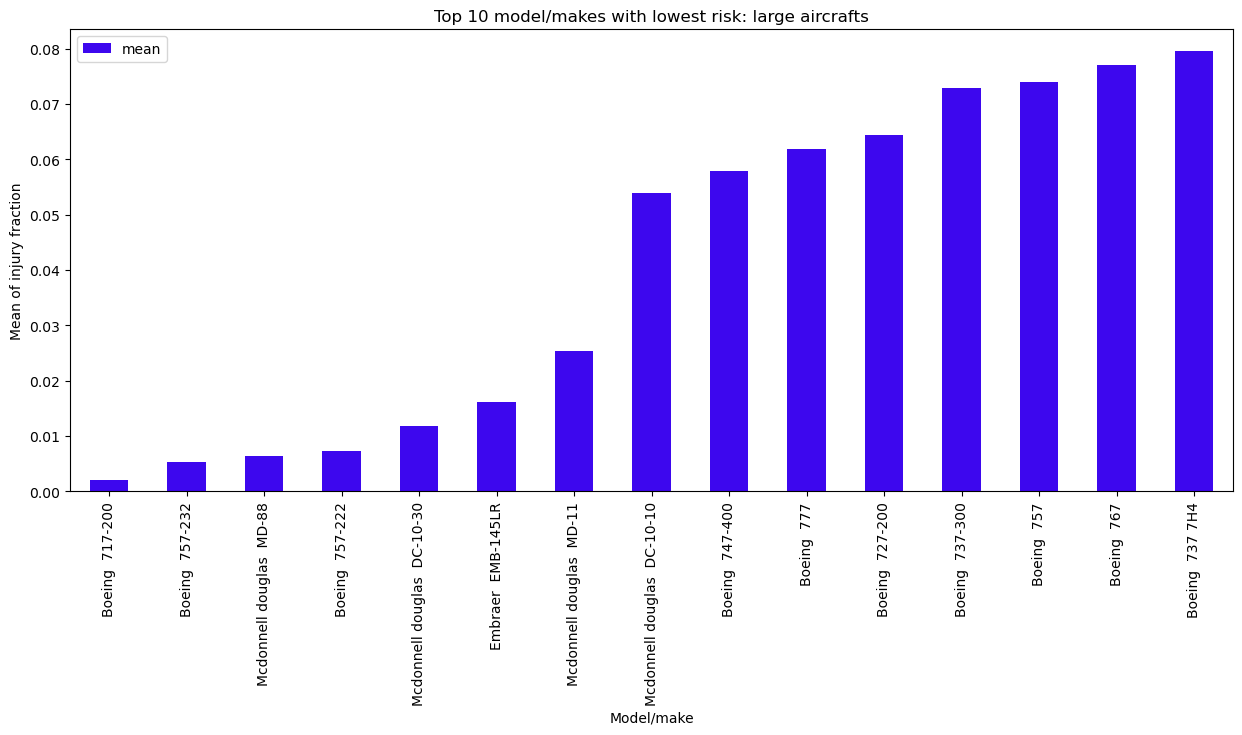

In [42]:
large_model_make15 = df_large.groupby('model_make')['serious_and_fatal_fraction'].agg(['mean','count']).query('count >= 10').sort_values('mean').head(15)

#plotting bar graph to represent small make
large_model_make15.plot(kind='bar',y='mean', color="#3D07EE", figsize=(15,6))
plt.title('Top 10 model/makes with lowest risk: large aircrafts')
plt.xlabel('Model/make')
plt.ylabel('Mean of injury fraction')

plt.show()


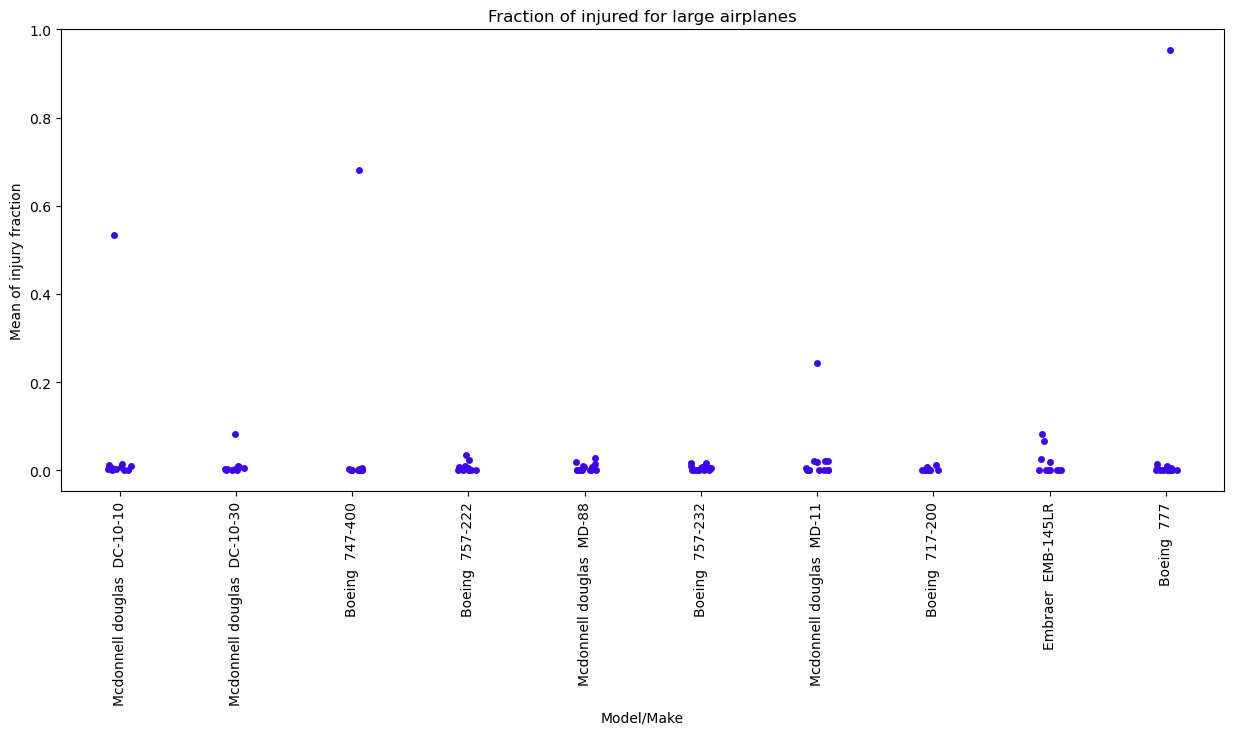

In [43]:
#stripplot for large
large_model_make15=large_model_make15.head(10).index
large_plot1 = df_large[df_large['model_make'].isin(large_model_make15)]

fig, ax = plt.subplots(figsize=(15,6))

sns.stripplot(data=large_plot1, x='model_make',y='serious_and_fatal_fraction', color="#3D07EE")
plt.title('Fraction of injured for large airplanes')
plt.xlabel('Model/Make')
plt.ylabel('Mean of injury fraction')
plt.xticks(rotation=90)

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

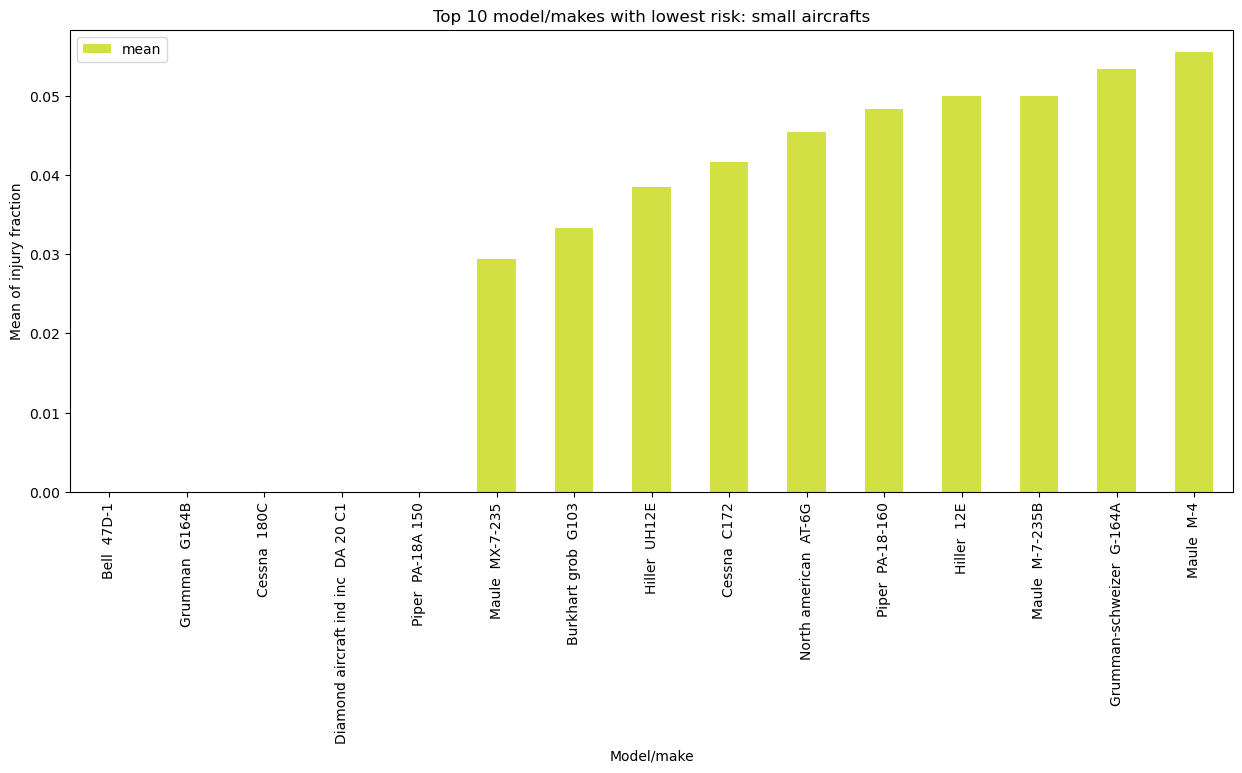

In [44]:
small_model_make15 = df_small.groupby('model_make')['serious_and_fatal_fraction'].agg(['mean','count']).query('count >= 10').sort_values('mean').head(15)

#plotting bar graph to represent small make
small_model_make15.plot(kind='bar',y= 'mean', color="#D3E044", figsize=(15,6))
plt.title('Top 10 model/makes with lowest risk: small aircrafts')
plt.xlabel('Model/make')
plt.ylabel('Mean of injury fraction')

plt.show()

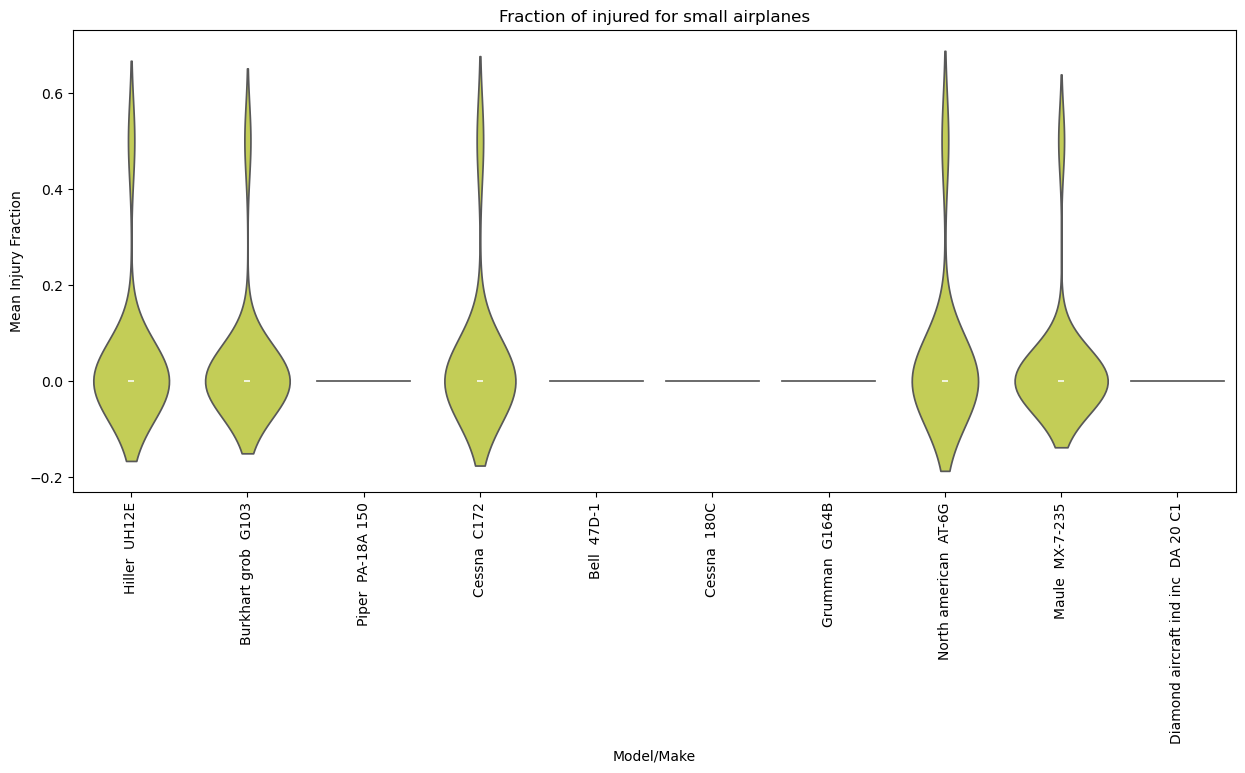

In [45]:
#Violin for small aircrafts
top10_small_models = small_model_make15.head(10).index
plot_small_models = df_small[df_small['model_make'].isin(top10_small_models)]

fig, ax = plt.subplots(figsize=(15,6))

sns.violinplot(data=plot_small_models, x='model_make', y='serious_and_fatal_fraction',color='#D3E044')
plt.title('Fraction of injured for small airplanes')
plt.xlabel('Model/Make')
plt.ylabel('Mean Injury Fraction')
plt.xticks(rotation=90)

plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

- Large airplane model: There are higher injury rates among Boeing with its various model makes(Boeing 767, Boeing 737 7H4) having the highest mean of the fraction of injury. However other model makes of the same Boeing (Boeing 717-200, Boeing 575-222) have the lowest fraction of serious injury and Mcdonnell Douglas MD-88 and DC-10-30
- Small airplane model: Bell 47D-1, Grumman G164B, Cessna 180C, and Diamond DA 20 C1 have near zero injury rates and highest rate of injury are linked to Maule M-4.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

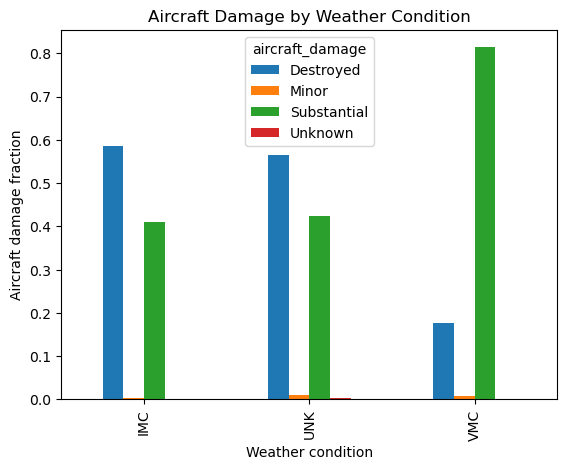

In [46]:
#Weather condition against aircraft damage
pd.crosstab(df['weather_condition'], df['aircraft_damage'], normalize='index').plot(kind="bar")


plt.title('Aircraft Damage by Weather Condition')
plt.ylabel('Aircraft damage fraction')
plt.xlabel('Weather condition');

observation: 
- The weather conditions are associated with higher aircraft damage rates than normal weather.
- IMC and UNK weather conditions are linked to the most destroyed aircraft with a fraction of above 0.5
- However, VMC weather condition is linked to the highest susbstantial aircraft damage with a fraction of 0.8

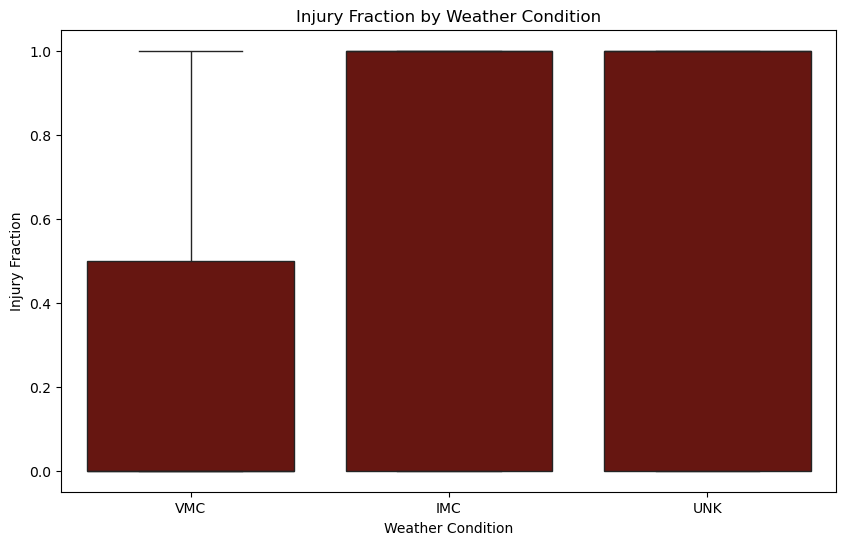

In [51]:
#Weather condition against injury

fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(data=df, x='weather_condition', y='serious_and_fatal_fraction',color='#740A03')
plt.title('Injury Fraction by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Injury Fraction')

plt.show()

Observation: The weather conditions, IMC AND UNK, have the biggest influence on the amount of injury outcomes of passengers with a fraction of injury at 1 compared to VMC which has a fraction of injury below 0.6

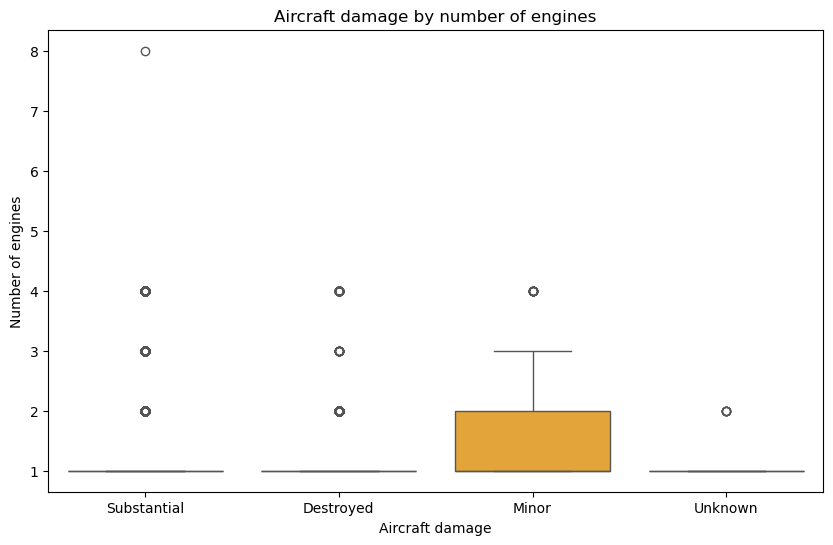

In [57]:
#Number of engine against aircraft damage

fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(data=df, y= 'number_of_engines',x='aircraft_damage', color="#FFAC1D")
plt.title('Aircraft damage by number of engines')
plt.ylabel('Number of engines')
plt.xlabel('Aircraft damage');


Observation: Theres no relationship directly linking the number of engine to aircraft damage.

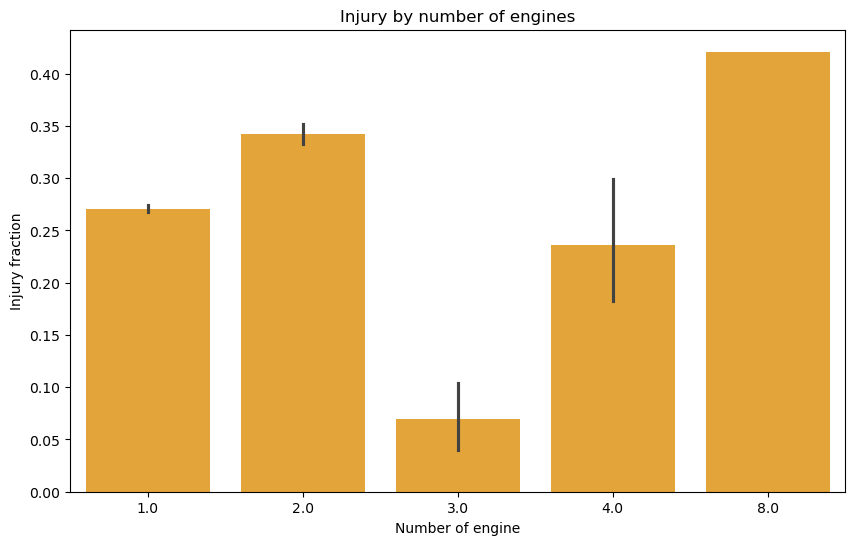

In [55]:
#Number of engine against injury

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(data=df, x= 'number_of_engines',y='serious_and_fatal_fraction', color="#FFAC1D")
plt.title('Injury by number of engines')
plt.ylabel('Injury fraction')
plt.xlabel('Number of engine');


observation: Theres no direct relationship of the injury rate against the number of engine